In [13]:
# Sami Ullah
# Roll no: 22013122-022

import numpy as np
import matplotlib.pyplot as plt

inputs = np.array([
    [9, 1], [15, 16], [13, 8],
    [5, 14], [3, 12], [1, 6],
    [17, 2], [11, 10], [7, 4]
])

targets = np.array([1, 0, 1, 1, 1, 0, 0, 1, 1])

# RBF Layer (Hidden Layer)
def gaussian_rbf(x, c, sigma=1.0):
    distance = np.linalg.norm(x - c)
    return np.exp(-(distance ** 2) / (2 * sigma ** 2))

# W3 input points as the centers for 3 hidden neurons
centers = inputs
sigma = 3.0

# Shape 3 samples, 3 hidden neurons
n_samples = inputs.shape[0]
n_hidden = centers.shape[0]
rbf_activations = np.zeros((n_samples, n_hidden))

for i in range(n_samples):
    for j in range(n_hidden):
        rbf_activations[i, j] = gaussian_rbf(inputs[i], centers[j], sigma)

print(rbf_activations)

# 3. Output Layer (Logistic/Sigmoid) setup
weights = np.random.random(n_hidden)  # 3 weights for 3 RBF neurons
learning_rate = 0.1
epochs = 100000


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Training Loop
for epoch in range(epochs):
    # Forward Pass
    # Linear combination: z = w1*h1 + w2*h2 + w3*h3
    z = np.dot(rbf_activations, weights)
    predictions = sigmoid(z)

    # Loss (MSE)
    loss = np.mean(0.5 * (targets - predictions) ** 2)

    # --- Backpropagation ---
    # Gradient of Loss w.r.t Predicted: -(Target - Prediction)
    error = predictions - targets
    # Gradient of Sigmoid: Prediction * (1 - Prediction)
    d_sigmoid = error * sigmoid_derivative(z)

    # Gradient of Weights: d_sigmoid * Input to the weights (rbf_activations)
    gradients = np.dot(rbf_activations.T, d_sigmoid)
    weights -= learning_rate * gradients

    # if epoch % 100 == 0:
    #     print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("\nFinal Predictions:")
print(np.round(predictions, 2))
print("Target Values:")
print(targets)

[[1.00000000e+00 5.04347663e-07 2.70218060e-02 3.43888636e-05
  1.62924733e-04 7.12287072e-03 2.70218060e-02 8.89538904e-03
  4.85671785e-01]
 [5.04347663e-07 1.00000000e+00 2.28734649e-02 3.09558685e-03
  1.37912809e-04 7.21553470e-08 1.49453385e-05 5.56379983e-02
  9.58265796e-06]
 [2.70218060e-02 2.28734649e-02 1.00000000e+00 3.86592014e-03
  1.58932728e-03 2.68617473e-04 5.56379983e-02 6.41180388e-01
  5.56379983e-02]
 [3.43888636e-05 3.09558685e-03 3.86592014e-03 1.00000000e+00
  6.41180388e-01 1.17436285e-02 1.12535175e-07 5.56379983e-02
  3.09558685e-03]
 [1.62924733e-04 1.37912809e-04 1.58932728e-03 6.41180388e-01
  1.00000000e+00 1.08368023e-01 7.21553470e-08 2.28734649e-02
  1.17436285e-02]
 [7.12287072e-03 7.21553470e-08 2.68617473e-04 1.17436285e-02
  1.08368023e-01 1.00000000e+00 2.73733423e-07 1.58932728e-03
  1.08368023e-01]
 [2.70218060e-02 1.49453385e-05 5.56379983e-02 1.12535175e-07
  7.21553470e-08 2.73733423e-07 1.00000000e+00 3.86592014e-03
  3.09558685e-03]
 [8.89

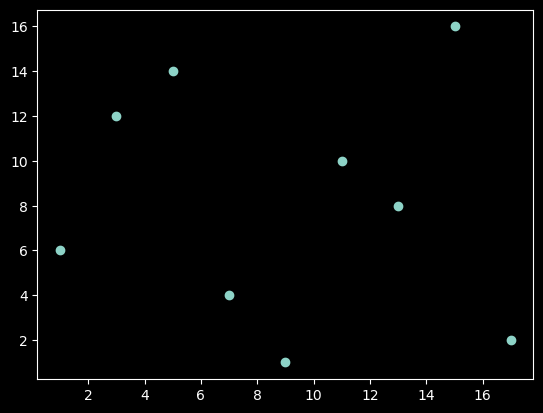

In [12]:
# plotting
plt.scatter(inputs[:, 0], inputs[:, 1])